## Walmart Sales Forecating 

In [85]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

In [86]:
data =  pd.read_csv(r'C:\Users\Windows 10\Downloads\walmart-recruiting-store-sales-forecasting\train.csv\train.csv')

features = pd.read_csv(r'C:\Users\Windows 10\Downloads\walmart-recruiting-store-sales-forecasting\features.csv\features.csv')

stores = pd.read_csv(r'C:\Users\Windows 10\Downloads\walmart-recruiting-store-sales-forecasting\stores.csv')


In [87]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [88]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8190 entries, 0 to 8189
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         8190 non-null   int64  
 1   Date          8190 non-null   object 
 2   Temperature   8190 non-null   float64
 3   Fuel_Price    8190 non-null   float64
 4   MarkDown1     4032 non-null   float64
 5   MarkDown2     2921 non-null   float64
 6   MarkDown3     3613 non-null   float64
 7   MarkDown4     3464 non-null   float64
 8   MarkDown5     4050 non-null   float64
 9   CPI           7605 non-null   float64
 10  Unemployment  7605 non-null   float64
 11  IsHoliday     8190 non-null   bool   
dtypes: bool(1), float64(9), int64(1), object(1)
memory usage: 712.0+ KB


In [89]:
stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Store   45 non-null     int64 
 1   Type    45 non-null     object
 2   Size    45 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 1.2+ KB


In [90]:
## Merging the DataFrames

data = pd.merge(data,features,on=['Date','Store','IsHoliday'],how='inner')
data = pd.merge(data,stores , on='Store' ,how='inner')

In [91]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


In [92]:
#  dropping Markdown columns
data = data.drop(columns=['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5'])
data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [93]:
data['Date']=pd.to_datetime(data['Date']) ### converting Date column from object to DateTime

In [94]:
##Setting Index to Date

data = data.set_index('Date')

data.head()

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
Date,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
2010-02-12,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2010-02-19,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
2010-02-26,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
2010-03-05,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315


In [95]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 421570 entries, 2010-02-05 to 2012-10-26
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Weekly_Sales  421570 non-null  float64
 3   IsHoliday     421570 non-null  bool   
 4   Temperature   421570 non-null  float64
 5   Fuel_Price    421570 non-null  float64
 6   CPI           421570 non-null  float64
 7   Unemployment  421570 non-null  float64
 8   Type          421570 non-null  object 
 9   Size          421570 non-null  int64  
dtypes: bool(1), float64(5), int64(3), object(1)
memory usage: 32.6+ MB


Text(0.5, 1.0, 'Total Sales over time')

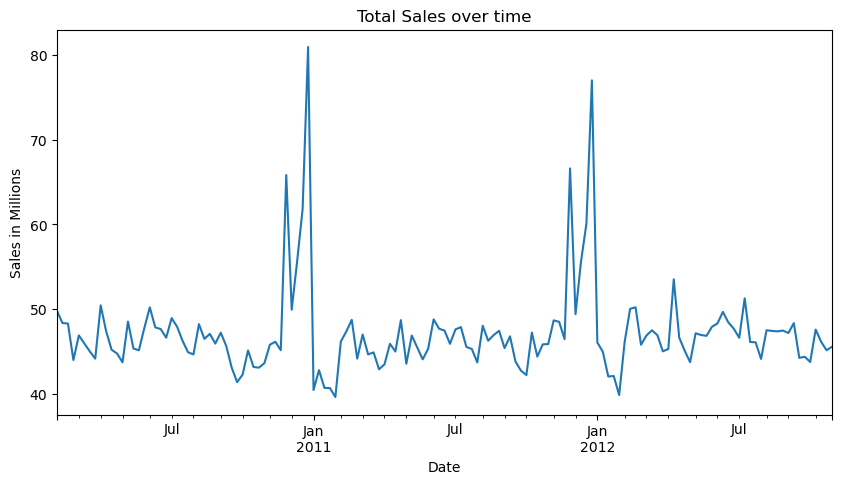

In [96]:
plt.figure(figsize=(10,5))

(data['Weekly_Sales'].resample('W').sum()/1e6).plot()
plt.ylabel('Sales in Millions')
plt.title('Total Sales over time')

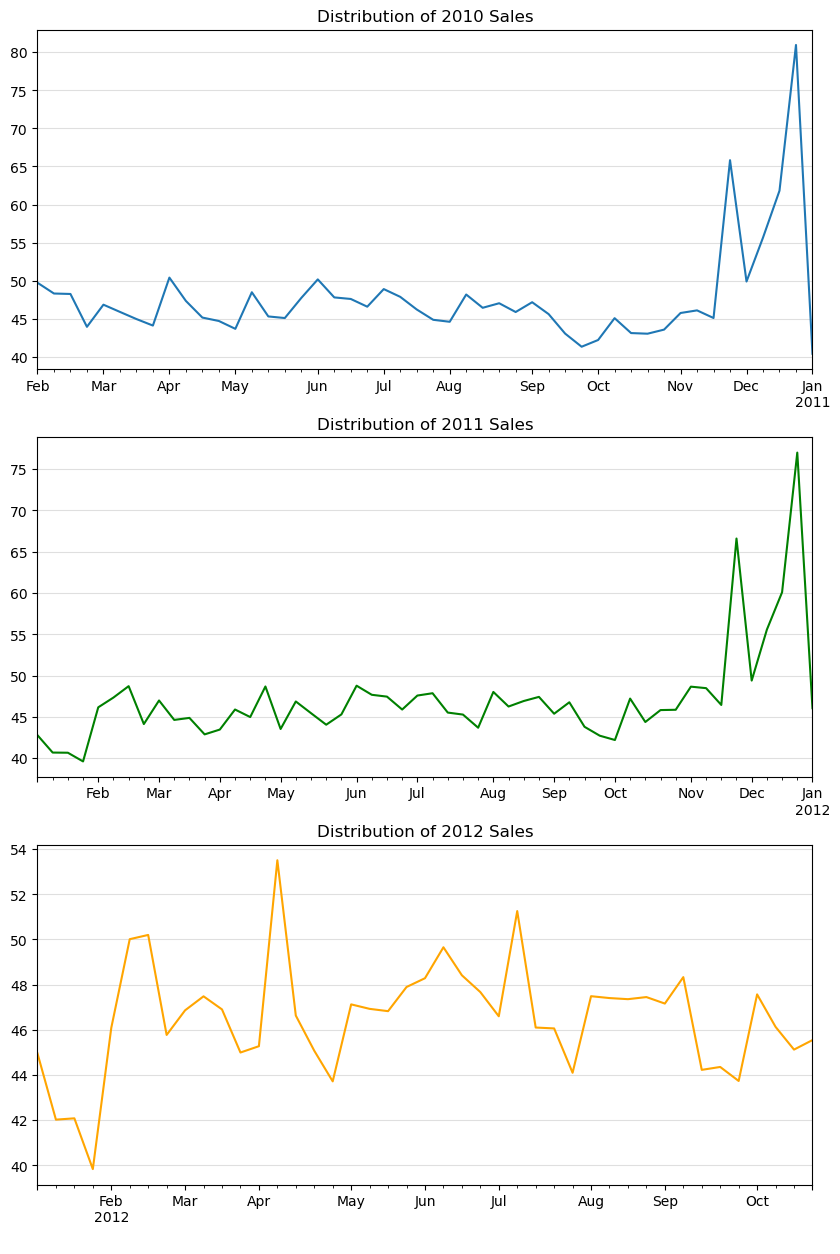

In [97]:
data_2010 = data[ data.index<='2010-12-31']
data_2011 = data[ (data.index >='2011-01-01') & (data.index<='2011-12-31') ]
data_2012 = data[ data.index>= '2012-01-01']

fig , ax =plt.subplots(3,1, figsize=(10,15))

(data_2010['Weekly_Sales'].resample('W').sum()/1e6).plot(ax=ax[0])
(data_2011['Weekly_Sales']/1e6).resample('W').sum().plot(ax=ax[1],color='green')
(data_2012['Weekly_Sales']/1e6).resample('W').sum().plot(ax=ax[2],color='orange')


ax[0].set_title("Distribution of 2010 Sales")
ax[1].set_title("Distribution of 2011 Sales")
ax[2].set_title("Distribution of 2012 Sales")


ax[0].set_xlabel(" ")
ax[1].set_xlabel(" ")
ax[2].set_xlabel(" ")

ax[0].grid(axis='y',alpha=0.4)
ax[1].grid(axis='y',alpha=0.4)
ax[2].grid(axis='y',alpha=0.4)


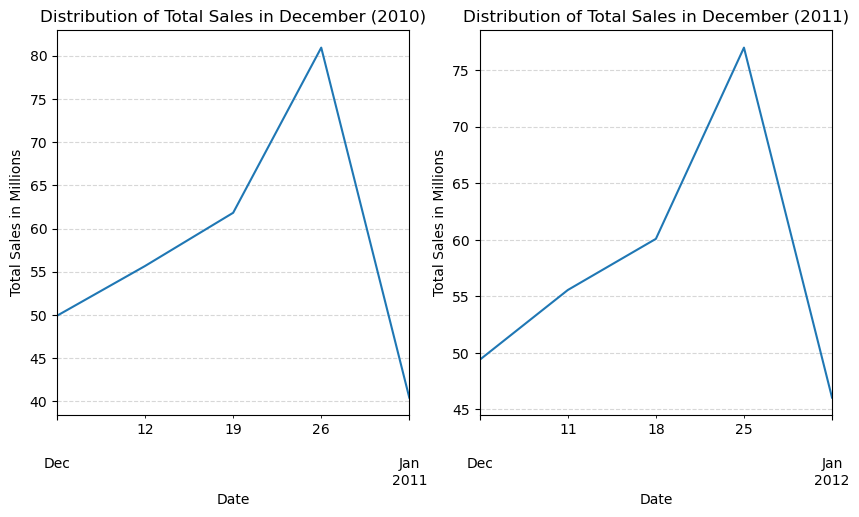

In [98]:
dec_2010 = data[ (data.index >= '2010-12-01') & (data.index <= '2011-01-01')].resample('W').sum()

dec_2011 = data[ (data.index >= '2011-12-01') & (data.index <= '2012-01-01')].resample('W').sum()


fig , ax =plt.subplots(1,2,figsize=(10,5))

(dec_2010['Weekly_Sales']/1e6).plot(ax=ax[0])
ax[0].set_title('Distribution of Total Sales in December (2010)')
ax[0].set_ylabel("Total Sales in Millions")
ax[0].grid(axis='y',alpha=0.5,linestyle='--')

(dec_2011['Weekly_Sales']/1e6).plot(ax=ax[1])
ax[1].set_title('Distribution of Total Sales in December (2011)')
ax[1].set_ylabel("Total Sales in Millions")
ax[1].grid(axis='y',alpha=0.5,linestyle='--')


Text(0.5, 1.0, 'Count of Store Types')

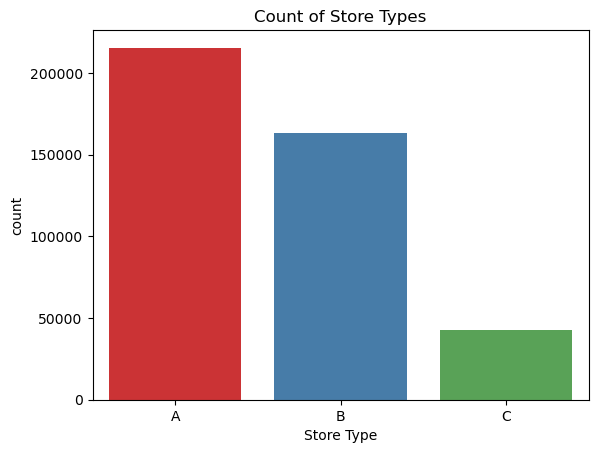

In [99]:
sns.countplot(data=data,x='Type',orient='v',hue='Type',palette='Set1')
plt.xlabel('Store Type')
plt.title('Count of Store Types')

(array([0, 1, 2]), [Text(0, 0, 'A'), Text(1, 0, 'B'), Text(2, 0, 'C')])

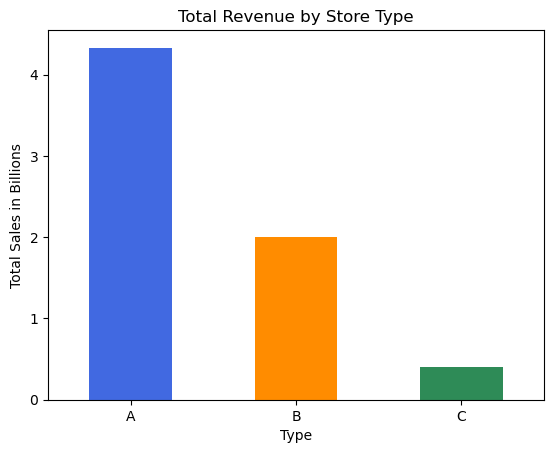

In [100]:
Type_sales= data.groupby('Type')['Weekly_Sales'].sum()/1e9
Type_sales.plot(kind='bar',color=['royalblue','darkorange','seagreen'])
plt.ylabel('Total Sales in Billions')
plt.title('Total Revenue by Store Type')
plt.xticks(rotation=0)

In [101]:
Dept_sales= (data.groupby('Dept')['Weekly_Sales'].sum()/1e6).sort_values(ascending=False).head()
Dept_sales

Dept
92    483.943342
95    449.320163
38    393.118137
72    305.725152
90    291.068464
Name: Weekly_Sales, dtype: float64

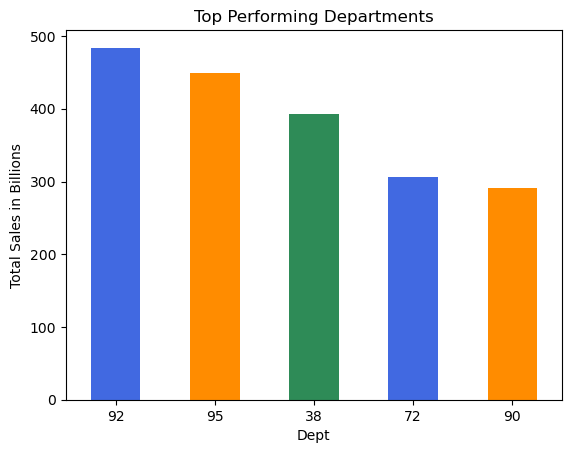

In [102]:

Dept_sales.plot(kind='bar',color=['royalblue','darkorange','seagreen'])
plt.ylabel('Total Sales in Billions')
plt.title('Top Performing Departments')
plt.xticks(rotation=0)
plt.show()

In [103]:
data

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
Date,,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
2010-02-12,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A,151315
2010-02-19,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A,151315
2010-02-26,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A,151315
2010-03-05,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A,151315
...,...,...,...,...,...,...,...,...,...,...
2012-09-28,45,98,508.37,False,64.88,3.997,192.013558,8.684,B,118221
2012-10-05,45,98,628.10,False,64.89,3.985,192.170412,8.667,B,118221
2012-10-12,45,98,1061.02,False,54.47,4.000,192.327265,8.667,B,118221


([<matplotlib.axis.XTick at 0x1a4cf7ba490>,
 [Text(0, 0, 'Not Holiday'), Text(1, 0, 'Holiday')])

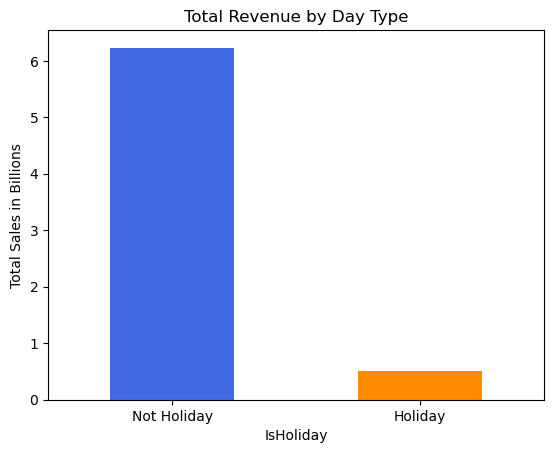

In [104]:
Day_sales= data.groupby('IsHoliday')['Weekly_Sales'].sum()/1e9
Day_sales.plot(kind='bar',color=['royalblue','darkorange'])
plt.ylabel('Total Sales in Billions')
plt.title('Total Revenue by Day Type')
plt.xticks(rotation=0,ticks=[0,1],labels=['Not Holiday', 'Holiday'])

In [128]:
data = data.drop(columns='Size')

In [129]:
corr_sales= data.select_dtypes('number').corr()['Weekly_Sales'].drop('Weekly_Sales').sort_values()

In [153]:
data['IsHoliday']=data['IsHoliday'].astype(int)

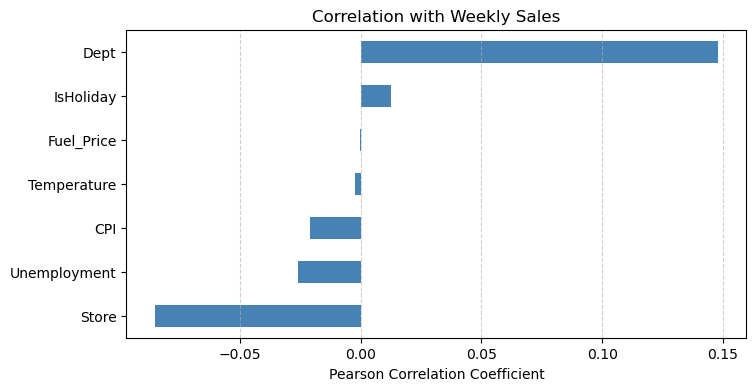

In [154]:

corr_sales = (
    data.select_dtypes('number')
    .corr()['Weekly_Sales']
    .drop('Weekly_Sales')
    .sort_values()
)

plt.figure(figsize=(8, 4))
corr_sales.plot(kind='barh', color='steelblue')
plt.title('Correlation with Weekly Sales')
plt.xlabel('Pearson Correlation Coefficient')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.show()

In [155]:
corr_sales

Store          -0.085195
Unemployment   -0.025864
CPI            -0.020921
Temperature    -0.002312
Fuel_Price     -0.000120
IsHoliday       0.012774
Dept            0.148032
Name: Weekly_Sales, dtype: float64

<Axes: >

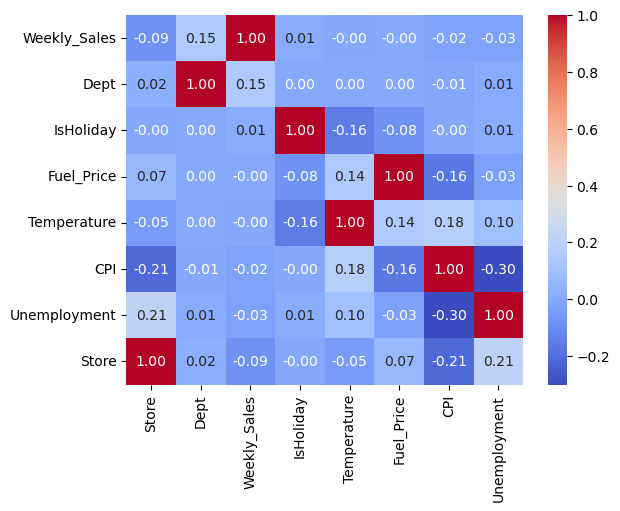

In [156]:
sns.heatmap(data=data.select_dtypes('number').corr().sort_values(by='Weekly_Sales',ascending=False)
            ,annot=True,cmap='coolwarm',fmt='.2f')

In [134]:
data

,Store,Dept,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type
Date,,,,,,,,,
2010-02-05,1,1,24924.50,False,42.31,2.572,211.096358,8.106,A
2010-02-12,1,1,46039.49,True,38.51,2.548,211.242170,8.106,A
2010-02-19,1,1,41595.55,False,39.93,2.514,211.289143,8.106,A
2010-02-26,1,1,19403.54,False,46.63,2.561,211.319643,8.106,A
2010-03-05,1,1,21827.90,False,46.50,2.625,211.350143,8.106,A
...,...,...,...,...,...,...,...,...,...
2012-09-28,45,98,508.37,False,64.88,3.997,192.013558,8.684,B
2012-10-05,45,98,628.10,False,64.89,3.985,192.170412,8.667,B
2012-10-12,45,98,1061.02,False,54.47,4.000,192.327265,8.667,B


In [135]:
(data.groupby(['Type'])['Weekly_Sales'].sum()/1e6).sort_values(ascending=False)

Type
A    4331.014723
B    2000.700737
C     405.503528
Name: Weekly_Sales, dtype: float64

## Build Model

In [166]:
training_data = data[['Weekly_Sales']].resample("W").sum()
training_data

,Weekly_Sales
Date,
2010-02-07,49750740.50
2010-02-14,48336677.63
2010-02-21,48276993.78
2010-02-28,43968571.13
2010-03-07,46871470.30
...,...
2012-09-30,43734899.40
2012-10-07,47566639.31
2012-10-14,46128514.25


In [167]:

training_data['Weekly_Sales_L1']= training_data['Weekly_Sales'].shift(1)
training_data.dropna(inplace=True)
training_data

,Weekly_Sales,Weekly_Sales_L1
Date,,
2010-02-14,48336677.63,49750740.50
2010-02-21,48276993.78,48336677.63
2010-02-28,43968571.13,48276993.78
2010-03-07,46871470.30,43968571.13
2010-03-14,45925396.51,46871470.30
...,...,...
2012-09-30,43734899.40,44354547.11
2012-10-07,47566639.31,43734899.40
2012-10-14,46128514.25,47566639.31


Text(0.5, 1.0, 'Weekly Sales Autocorrelation')

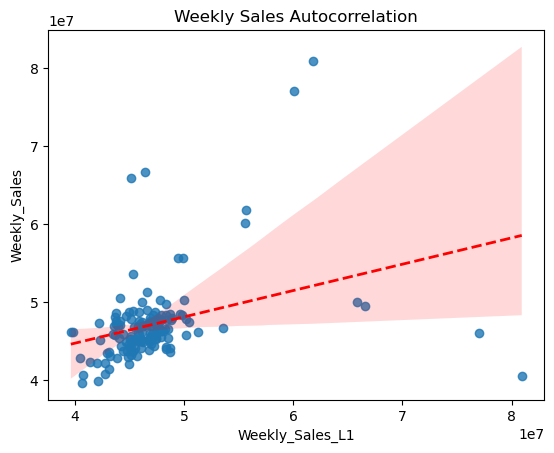

In [169]:
sns.regplot(x=training_data['Weekly_Sales_L1'],y= training_data['Weekly_Sales'],line_kws={'color':'red','linewidth':2,'linestyle':'--'})
plt.title("Weekly Sales Autocorrelation")

In [171]:
## Vertical split

cutoff = int (len(training_data) * 0.9)

In [173]:
X=training_data[['Weekly_Sales_L1']]
y=training_data['Weekly_Sales']

In [176]:
X_train , y_train= X.iloc[:cutoff] , y.iloc[:cutoff]

X_test , y_test = X.iloc[cutoff:] , y.iloc[cutoff:]

In [177]:
len(X_train) == len(y_train)

True

In [178]:
len(X_test) == len(y_test)

True

In [179]:
y_pred_baseline = [y_train.mean()] * len(y_train)

mae_baseline =mean_absolute_error(y_train , y_pred_baseline)

print("Baseline to beat : ",mae_baseline/1e6, "Million")

Baseline to beat :  3.116623259872281 Million


In [180]:
model= LinearRegression()

model.fit(X_train,y_train)

LinearRegression()

In [183]:
train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, train_pred)

mae_test = mean_absolute_error(y_test , model.predict(X_test))

print("Baseline to beat : ",mae_baseline/1e6, "Million")

print("Training MAE : ", mae_train/1e6,"Million")

print("Testing MAE : ", mae_test/1e6,"Million")



Baseline to beat :  3.116623259872281 Million
Training MAE :  2.9807126520910887 Million
Testing MAE :  1.3047678125944862 Million


In [184]:
intercept = model.intercept_.round(2)
coef = model.coef_.round(2)


print (f" Weekly Sales = {intercept} + {coef} * Weekly_Sales_L1")

 Weekly Sales = 31326717.61 + [0.34] * Weekly_Sales_L1


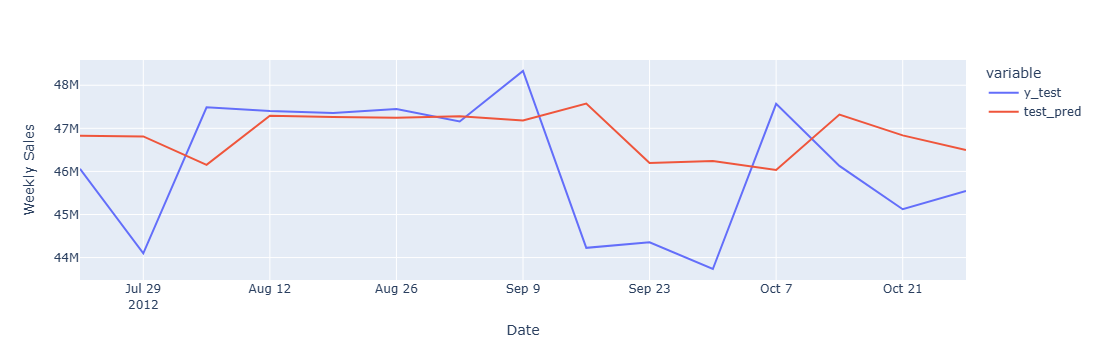

In [185]:
test_pred = model.predict(X_test)
df_pred = pd.DataFrame(
    {'y_test' : y_test , 'test_pred':test_pred}
)


fig = px.line(df_pred,labels={'value':'Weekly Sales'})
fig.show()

## AutoRegression

In [191]:
data_01=data['Weekly_Sales'].resample("W").sum()
data_01

Date
2010-02-07    49750740.50
2010-02-14    48336677.63
2010-02-21    48276993.78
2010-02-28    43968571.13
2010-03-07    46871470.30
                 ...     
2012-09-30    43734899.40
2012-10-07    47566639.31
2012-10-14    46128514.25
2012-10-21    45122410.57
2012-10-28    45544116.29
Freq: W-SUN, Name: Weekly_Sales, Length: 143, dtype: float64

Text(0, 0.5, 'Correlation Coefficient')

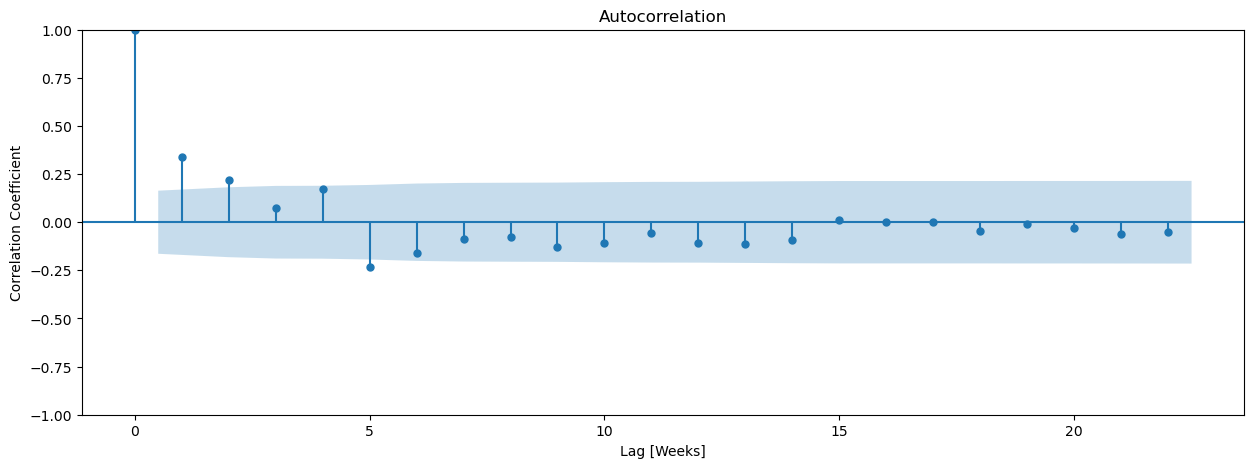

In [192]:
fig ,ax =plt.subplots(figsize=(15,5))

plot_acf(data_01,ax=ax)
plt.xlabel("Lag [Weeks]")
plt.ylabel("Correlation Coefficient")

Text(0, 0.5, 'Correlation Coefficient')

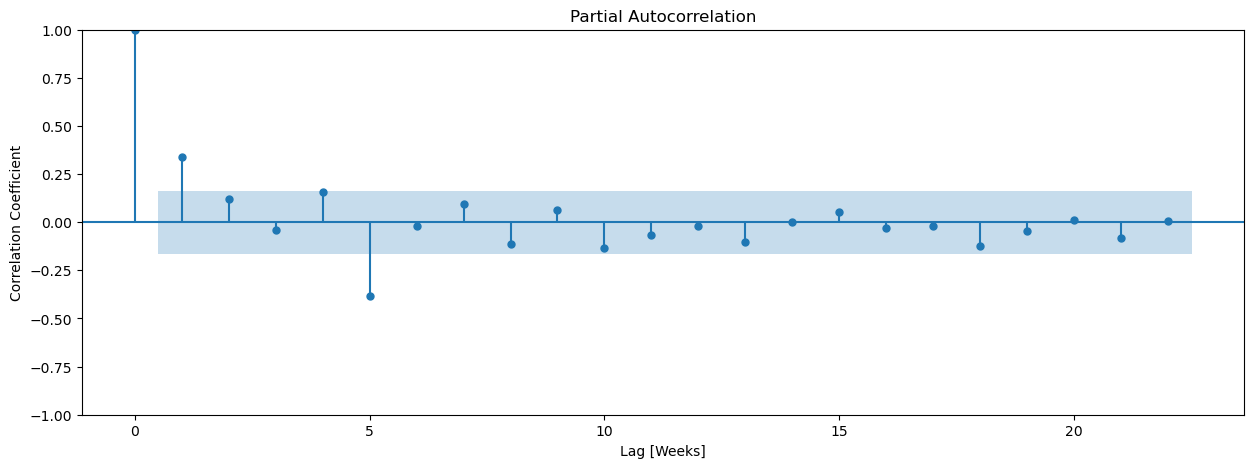

In [193]:
fig ,ax =plt.subplots(figsize=(15,5))

plot_pacf(data_01,ax=ax)
plt.xlabel("Lag [Weeks]")
plt.ylabel("Correlation Coefficient")

In [196]:
y_train = data_01.iloc[:cutoff]

y_test = data_01.iloc[cutoff:]

In [197]:
y_pred_baseline_1= [y_train.mean()]*len(y_train)

mae_baseline= mean_absolute_error(y_train,y_pred_baseline_1)

print( "Baseline MAE : ", round(mae_baseline/1e6,4),"Million")

Baseline MAE :  3.1362 Million


In [198]:
model = AutoReg( y_train , lags= 5 ).fit()

In [199]:
y_pred = model.predict().dropna()

training_mae = mean_absolute_error(y_train[5:],y_pred)

print( "Baseline MAE : ", round(mae_baseline/1e6,4),"Million")

print("Traning MAE : ",round(training_mae/1e6,2),"Million")

Baseline MAE :  3.1362 Million
Traning MAE :  3.04 Million


Text(0.5, 1.0, 'Distribution of Residuals')

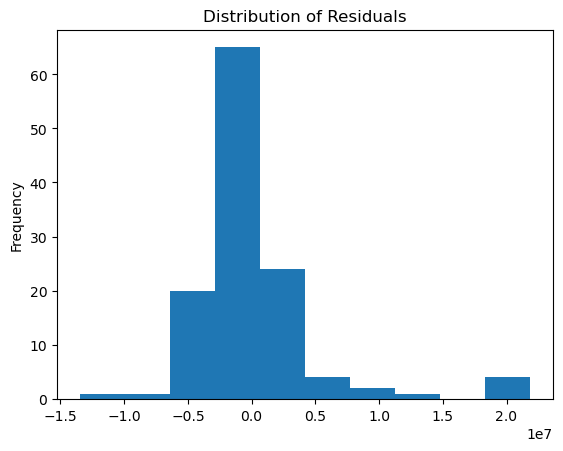

In [200]:
y_train_resid= model.resid

y_train_resid.plot(kind='hist')

plt.title("Distribution of Residuals")

Text(0.5, 1.0, 'Distribution of Residuals')

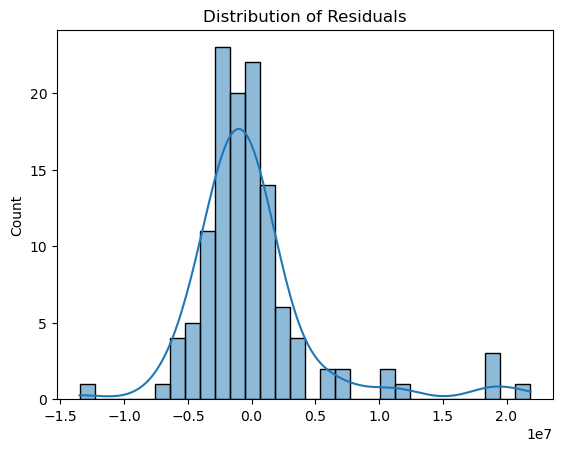

In [201]:
sns.histplot(y_train_resid,kde=True,bins=30)

plt.title("Distribution of Residuals")

In [202]:
y_test_pred= model.predict(y_test.index.min(), y_test.index.max() )

test_mae= mean_absolute_error(y_test,y_test_pred)
print( "Baseline MAE : ", round(mae_baseline/1e6,4),"Million")

print("Traning MAE : ",round(training_mae/1e6,2),"Million")
print("Testing MAE : ",round(test_mae/1e6,2),"Million")

Baseline MAE :  3.1362 Million
Traning MAE :  3.04 Million
Testing MAE :  1.7 Million


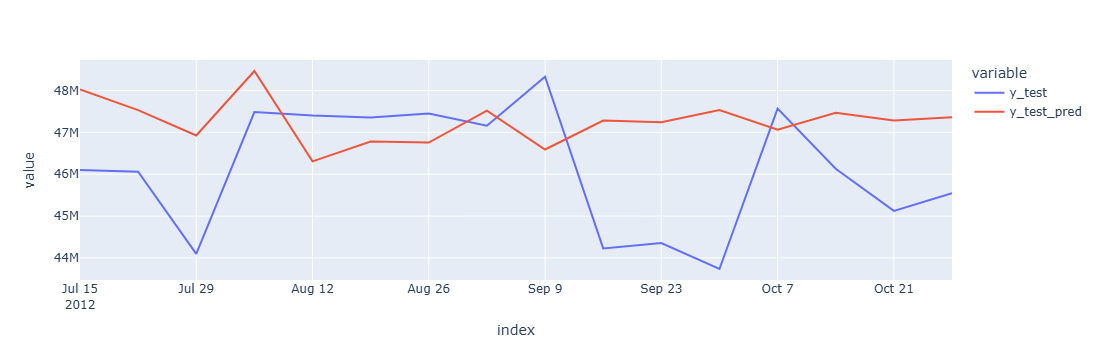

In [203]:
df_pred_test= pd.DataFrame(
    {'y_test':y_test,'y_test_pred':y_test_pred}
)


fig = px.line(df_pred_test,labels={'values':'Total Weekly Sales'})
fig.show()

## Walk Forward Validation

In [204]:
predictions = []
history = y_train.copy()

for i in range(len(y_test)):
    model = AutoReg(history, lags=5).fit()
    next_pred = model.forecast()

    # Store prediction
    predictions.append(next_pred)

    # Append actual ground-truth observation using pd.concat
    actual = y_test.iloc[[i]]
    history = pd.concat([history, actual])

# Combine all 1-step predictions into a single Series
y_pred_wfv = pd.concat(predictions)

In [205]:
test_mae_1=mean_absolute_error(y_test,y_pred_wfv)

print( "Baseline MAE : ", round(mae_baseline/1e6,4),"Million")

print("Traning MAE : ",round(training_mae/1e6,2),"Million")
print("Testing MAE : ",round(test_mae/1e6,2),"Million")



print(" New MAE : ",round(test_mae_1/1e6,2))

Baseline MAE :  3.1362 Million
Traning MAE :  3.04 Million
Testing MAE :  1.7 Million
 New MAE :  1.41


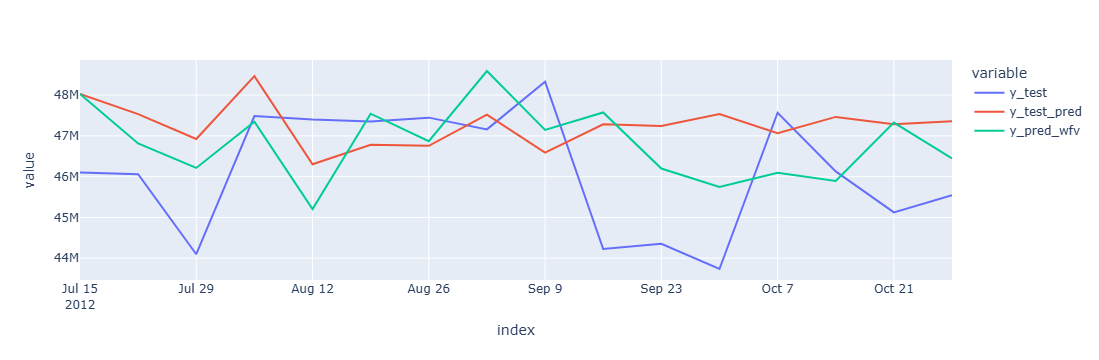

In [206]:

df_pred_test= pd.DataFrame(
    {'y_test':y_test,'y_test_pred':y_test_pred,'y_pred_wfv':y_pred_wfv}
)


fig = px.line(df_pred_test,labels={'values':'Total Weekly Sales'})
fig.show()